In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import accuracy_score 

In [2]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i (1).csv")

In [3]:
df.shape

(614, 13)

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.drop(columns=["Loan_ID"], inplace=True)

In [6]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [8]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
# number of missing values in each column
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df['Gender'].value_counts() , df['Gender'].unique()




(Gender
 Male      489
 Female    112
 Name: count, dtype: int64,
 array(['Male', 'Female', nan], dtype=object))

In [11]:
df['Gender'] = np.where(df['Gender'] == 'Male', 1, 0)
df['Education'] = np.where(df['Education'] == 'College', 1, 0)


In [12]:
df.dropna(inplace = True)

In [13]:
# number of missing values in each column
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

<Axes: xlabel='Education', ylabel='count'>

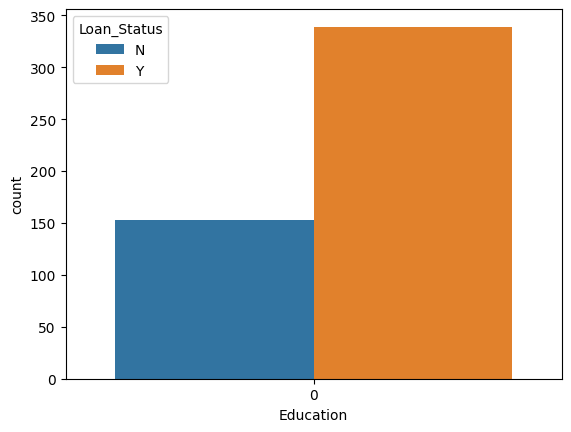

In [14]:
# education & Loan Status
sns.countplot(x='Education',hue='Loan_Status',data=df)

<Axes: xlabel='Married', ylabel='count'>

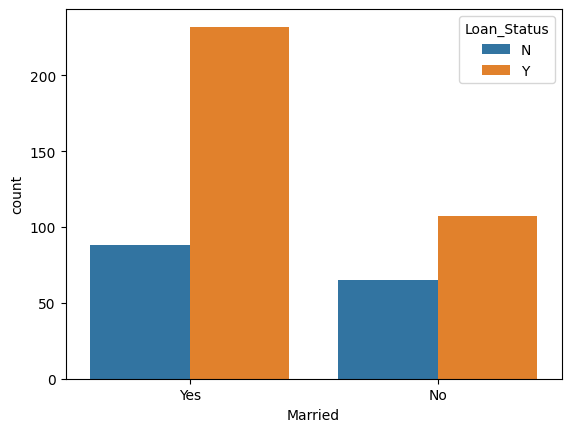

In [15]:
# marital status & Loan Status
sns.countplot(x='Married',hue='Loan_Status',data=df)

In [16]:
df.describe()

,Gender,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,492.000000,492.0,492.000000,492.000000,492.000000,492.000000,492.000000
mean,0.800813,0.0,5502.203252,1572.959187,146.390244,342.000000,0.851626
std,0.399795,0.0,6069.324665,2597.096132,84.352947,64.902747,0.355832
min,0.000000,0.0,150.000000,0.000000,9.000000,36.000000,0.000000
25%,1.000000,0.0,2898.750000,0.000000,100.000000,360.000000,1.000000
50%,1.000000,0.0,3859.000000,1084.500000,128.000000,360.000000,1.000000
75%,1.000000,0.0,5936.500000,2250.000000,170.500000,360.000000,1.000000
max,1.000000,0.0,81000.000000,33837.000000,700.000000,480.000000,1.000000


In [17]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train ,y_test = train_test_split(df.drop(columns=['Loan_Status']), df['Loan_Status'], test_size=0.2, random_state=2)   


In [18]:
from sklearn import svm

In [19]:
classifier = svm.SVC(kernel='linear')

In [20]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)


In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393 entries, 66 to 210
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             393 non-null    int64  
 1   Married            393 non-null    object 
 2   Dependents         393 non-null    object 
 3   Education          393 non-null    int64  
 4   Self_Employed      393 non-null    object 
 5   ApplicantIncome    393 non-null    int64  
 6   CoapplicantIncome  393 non-null    float64
 7   LoanAmount         393 non-null    float64
 8   Loan_Amount_Term   393 non-null    float64
 9   Credit_History     393 non-null    float64
 10  Property_Area      393 non-null    object 
dtypes: float64(4), int64(3), object(4)
memory usage: 36.8+ KB


In [22]:
df['Married'] = np.where(df['Married'] == 'Yes', 1, 0)

In [23]:
df['Dependents'].unique()

array(['1', '0', '2', '3+'], dtype=object)

In [24]:
df['Dependents'] = np.where(df['Dependents'] == '3+', 3, df['Dependents'])

In [25]:
df["Dependents"] = df["Dependents"].astype(int)

In [26]:
df['Self_Employed'] = np.where(df['Self_Employed'] == 'Yes', 1, 0)

In [27]:
df['Property_Area'].unique()

from sklearn.preprocessing import OrdinalEncoder

le = OrdinalEncoder()
le.fit(df[["Property_Area"]])
df["Property_Area"] = le.transform(df[["Property_Area"]])


In [28]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0.0,N
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2.0,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2.0,Y
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2.0,Y
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2.0,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0.0,Y
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0.0,Y
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2.0,Y
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2.0,Y


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[: ,:-1], df.iloc[:, -1], test_size=0.2, random_state=0)


In [30]:
y_train_enc= encoder.fit_transform(y_train)
y_test_enc= encoder.transform(y_test)



In [31]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression()

model.fit(X_train, y_train_enc)

C:\Users\manas\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
print(" hi there ")

 hi there 


In [38]:
# accuracy score on training data
X_train_prediction = model.predict(X_train)
training_data_accuray = accuracy_score(X_train_prediction,y_train_enc)

print('Accuracy score of training data : ', training_data_accuray * 100 , " %")


Accuracy score of training data :  80.40712468193384  %


In [40]:
# accuracy score on training data
X_test_prediction = model.predict(X_test)
test_data_accuray = accuracy_score(X_test_prediction,y_test_enc)

print('Accuracy score of test data : ', test_data_accuray * 100 , " %")

Accuracy score of test data :  80.8080808080808  %
